# **1. Introduction**

This notebook trains and evaluates machine learning models to predict credit card default using the preprocessed data from **Notebook 02**.

### Plan:
1. Load processed train/test splits
2. Define evaluation metrics (AUC-ROC, Recall, Precision-Recall — not accuracy due to class imbalance)
3. Train a baseline model — Logistic Regression
4. Train stronger candidate models — Random Forest and XGBoost
5. Compare models on the validation set
6. Hyperparameter tuning on the best candidate
7. Final evaluation on the held-out test set
8. Error analysis
9. Save the best model

**Class imbalance handling:** `class_weight='balanced'` — penalises mistakes on the minority class (defaulters) more heavily without modifying the data.

# **2. Import Libraries**

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    classification_report
)

# Tuning
from sklearn.model_selection import RandomizedSearchCV

# **3. Load Processed Data**

In [19]:
BASE = r'C:\Users\jensd\Downloads\Datasets School\Data Science Map\credit-risk-project'
processed_dir = os.path.join(BASE, 'data', 'processed')

X_train = pd.read_csv(os.path.join(processed_dir, 'X_train.csv'))
X_test  = pd.read_csv(os.path.join(processed_dir, 'X_test.csv'))
y_train = pd.read_csv(os.path.join(processed_dir, 'y_train.csv')).squeeze()
y_test  = pd.read_csv(os.path.join(processed_dir, 'y_test.csv')).squeeze()

scaler = joblib.load(os.path.join(BASE, 'models', 'scaler.pkl'))

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}  — default rate: {y_train.mean()*100:.2f}%')
print(f'y_test  : {y_test.shape}  — default rate: {y_test.mean()*100:.2f}%')

X_train : (24000, 25)
X_test  : (6000, 25)
y_train : (24000,)  — default rate: 22.12%
y_test  : (6000,)  — default rate: 22.12%


# **4. Define Evaluation Metrics**

### Why not accuracy?
With 77.88% non-defaulters, a model that **always predicts "no default"** would score 77.88% accuracy — but it would be completely useless. It catches zero defaulters.

### Metrics we use:

**AUC-ROC (Area Under the ROC Curve)**
Measures the model's ability to separate defaulters from non-defaulters across all possible thresholds. A score of 0.5 = random guessing, 1.0 = perfect. This is our primary metric.

**Recall (Sensitivity)**
Of all customers who actually defaulted, what % did the model correctly identify?
`Recall = True Positives / (True Positives + False Negatives)`
In credit risk, a missed defaulter (False Negative) is costly — the bank loses money. High recall is critical.

**Precision**
Of all customers the model flagged as defaulters, what % actually defaulted?
`Precision = True Positives / (True Positives + False Positives)`
Low precision means we flag too many good customers as risky — a business cost.

**F1 Score**
Harmonic mean of Precision and Recall. Useful single number when you care about both.
`F1 = 2 * (Precision * Recall) / (Precision + Recall)`

**Precision-Recall Curve**
Better than the ROC curve when classes are imbalanced — shows the trade-off between catching defaulters (recall) and not falsely flagging good customers (precision).

**Confusion Matrix**
Visual breakdown of True Positives, False Positives, True Negatives, False Negatives — gives an intuitive picture of where the model is making mistakes.

In [20]:
def evaluate_model(name, model, X, y_true):
    """
    Prints classification metrics and plots ROC curve,
    Precision-Recall curve, and Confusion Matrix for a fitted model.
    """
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    auc   = roc_auc_score(y_true, y_prob)
    rec   = recall_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred)
    f1    = f1_score(y_true, y_pred)

    print(f'=== {name} ===')
    print(f'  AUC-ROC   : {auc:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=['No Default', 'Default']))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[0].plot(fpr, tpr, label=f'AUC = {auc:.4f}')
    axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
    axes[0].set_title(f'{name} — ROC Curve')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].legend()

    # Precision-Recall Curve
    prec_vals, rec_vals, _ = precision_recall_curve(y_true, y_prob)
    axes[1].plot(rec_vals, prec_vals)
    axes[1].set_title(f'{name} — Precision-Recall Curve')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])
    axes[2].set_title(f'{name} — Confusion Matrix')
    axes[2].set_xlabel('Predicted')
    axes[2].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

    return {'name': name, 'auc': auc, 'recall': rec, 'precision': prec, 'f1': f1}

print('evaluate_model() function defined.')

evaluate_model() function defined.


# **5. Baseline Model — Logistic Regression**

Logistic Regression is the standard baseline for binary classification. It is simple, fast, and interpretable. Every model we train after this should outperform it — if a complex model can't beat logistic regression, something is wrong.

- `class_weight='balanced'` — compensates for the 78/22 imbalance
- `max_iter=1000` — the default 100 iterations is often not enough for convergence on this dataset
- We evaluate on the **training set first** to check for underfitting, then on the **test set** for true performance

--- Train performance ---
=== Logistic Regression (train) ===
  AUC-ROC   : 0.7509
  Recall    : 0.6280
  Precision : 0.4373
  F1 Score  : 0.5156

              precision    recall  f1-score   support

  No Default       0.88      0.77      0.82     18691
     Default       0.44      0.63      0.52      5309

    accuracy                           0.74     24000
   macro avg       0.66      0.70      0.67     24000
weighted avg       0.78      0.74      0.75     24000



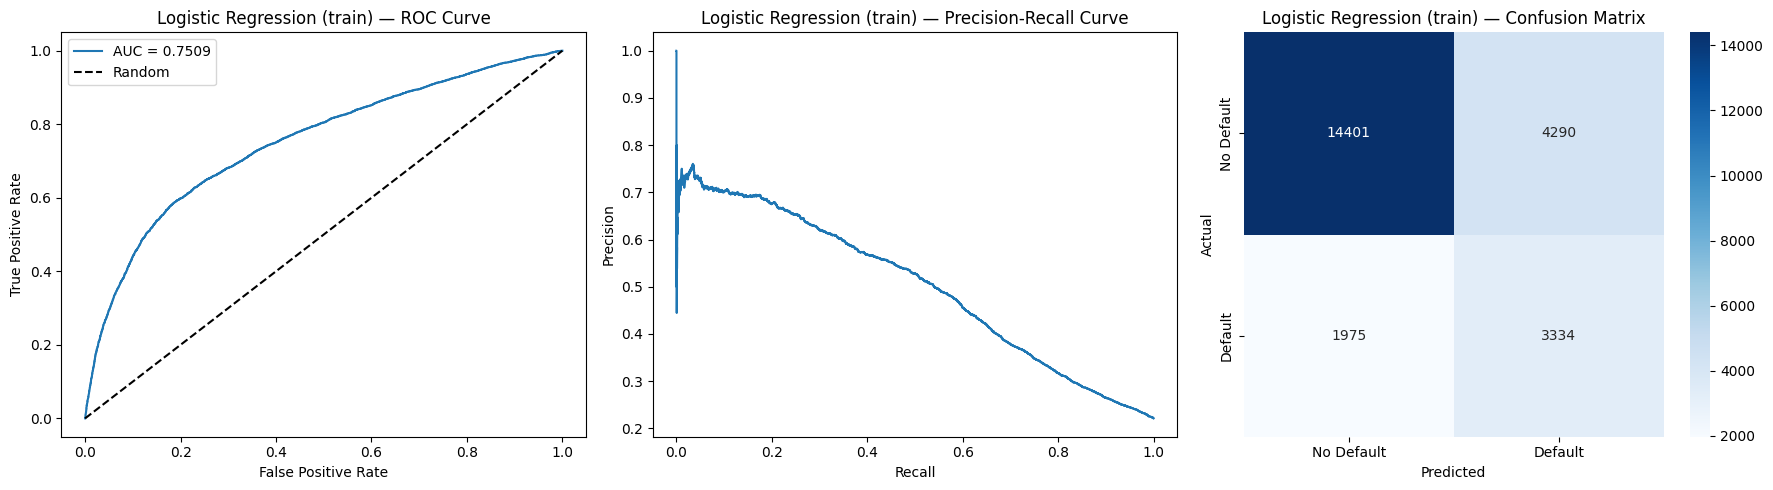

--- Test performance ---
=== Logistic Regression (test) ===
  AUC-ROC   : 0.7459
  Recall    : 0.6149
  Precision : 0.4368
  F1 Score  : 0.5108

              precision    recall  f1-score   support

  No Default       0.88      0.77      0.82      4673
     Default       0.44      0.61      0.51      1327

    accuracy                           0.74      6000
   macro avg       0.66      0.69      0.67      6000
weighted avg       0.78      0.74      0.75      6000



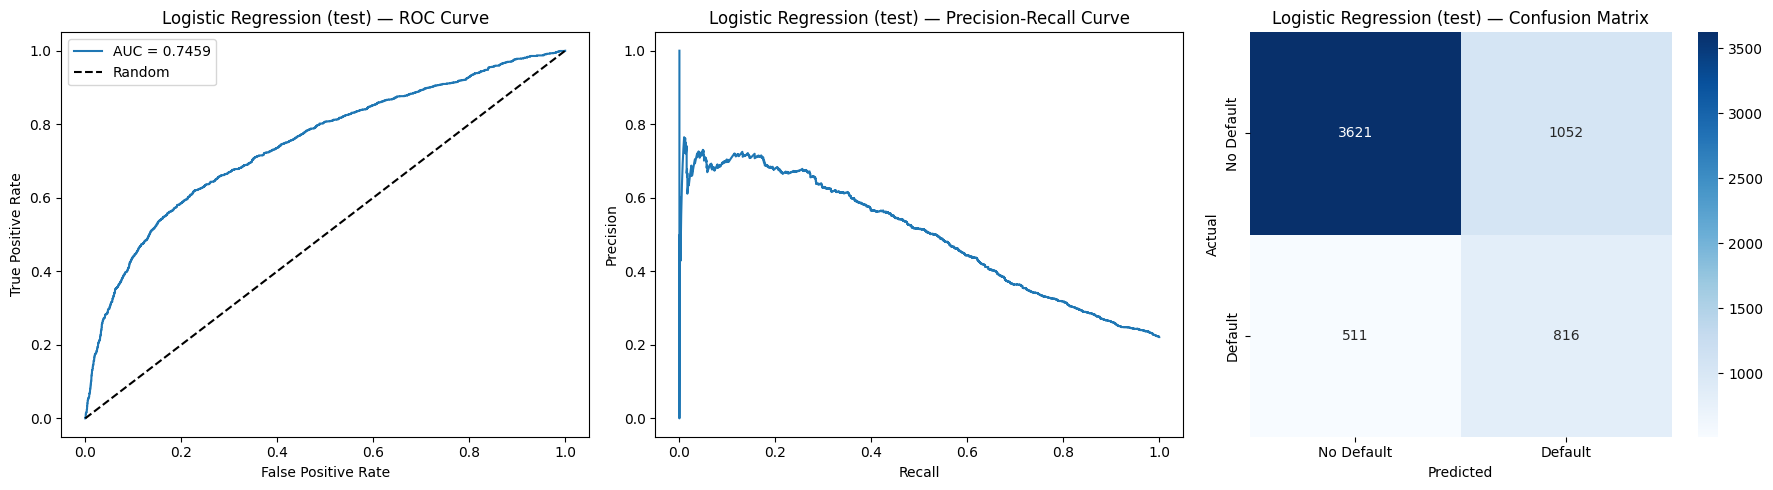

In [21]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=0)
lr.fit(X_train, y_train)

print('--- Train performance ---')
lr_train_scores = evaluate_model('Logistic Regression (train)', lr, X_train, y_train)

print('--- Test performance ---')
lr_test_scores = evaluate_model('Logistic Regression (test)', lr, X_test, y_test)

# **6. Candidate Models**

## **6.1 Random Forest**

Builds many decision trees independently on random subsets of rows and features, then combines their predictions. The randomness reduces overfitting and makes the model robust to multicollinearity and outliers.

- `class_weight='balanced'` — handles the 78/22 imbalance
- `n_estimators=200` — number of trees
- `max_depth=10` — limits tree depth to prevent memorising individual training rows
- `min_samples_leaf=10` — a leaf needs at least 10 samples, no splits on single data points
- `min_samples_split=20` — a node needs at least 20 samples before it can split
- `random_state=0` — reproducibility

--- Train performance ---
=== Random Forest (train) ===
  AUC-ROC   : 0.8470
  Recall    : 0.6559
  Precision : 0.5619
  F1 Score  : 0.6052

              precision    recall  f1-score   support

  No Default       0.90      0.85      0.88     18691
     Default       0.56      0.66      0.61      5309

    accuracy                           0.81     24000
   macro avg       0.73      0.76      0.74     24000
weighted avg       0.82      0.81      0.82     24000



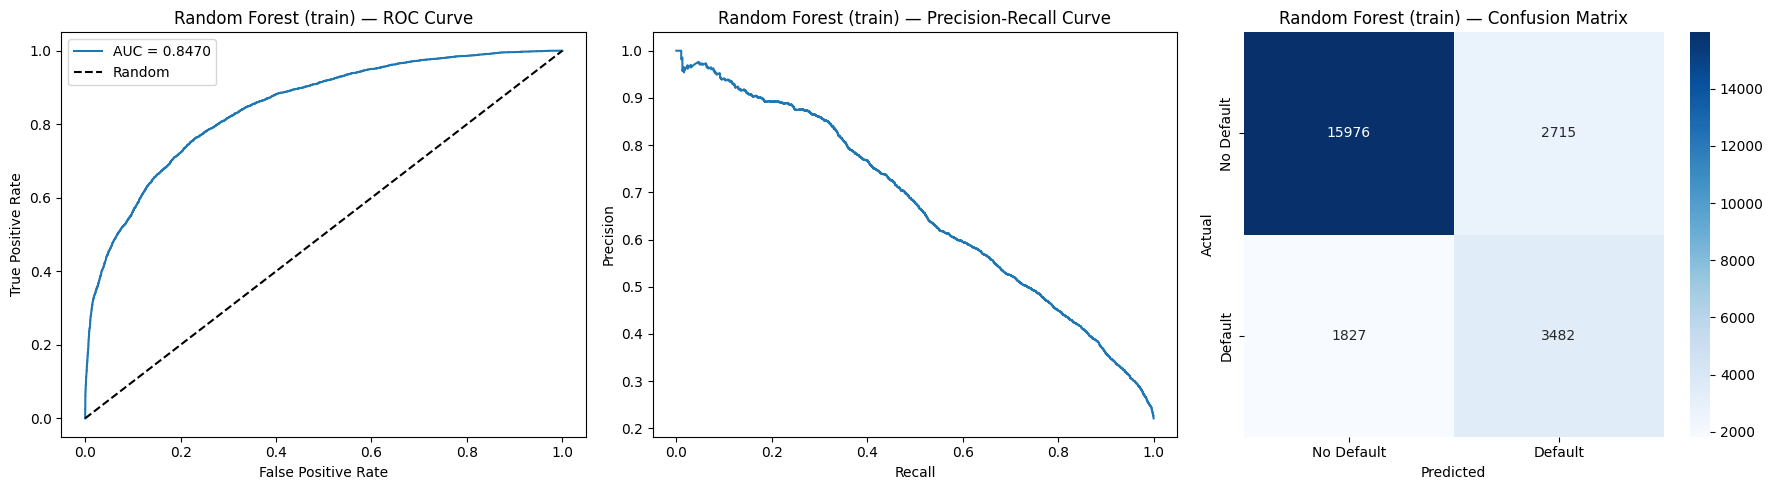

--- Test performance ---
=== Random Forest (test) ===
  AUC-ROC   : 0.7795
  Recall    : 0.5863
  Precision : 0.5029
  F1 Score  : 0.5414

              precision    recall  f1-score   support

  No Default       0.88      0.84      0.86      4673
     Default       0.50      0.59      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.78      0.79      6000



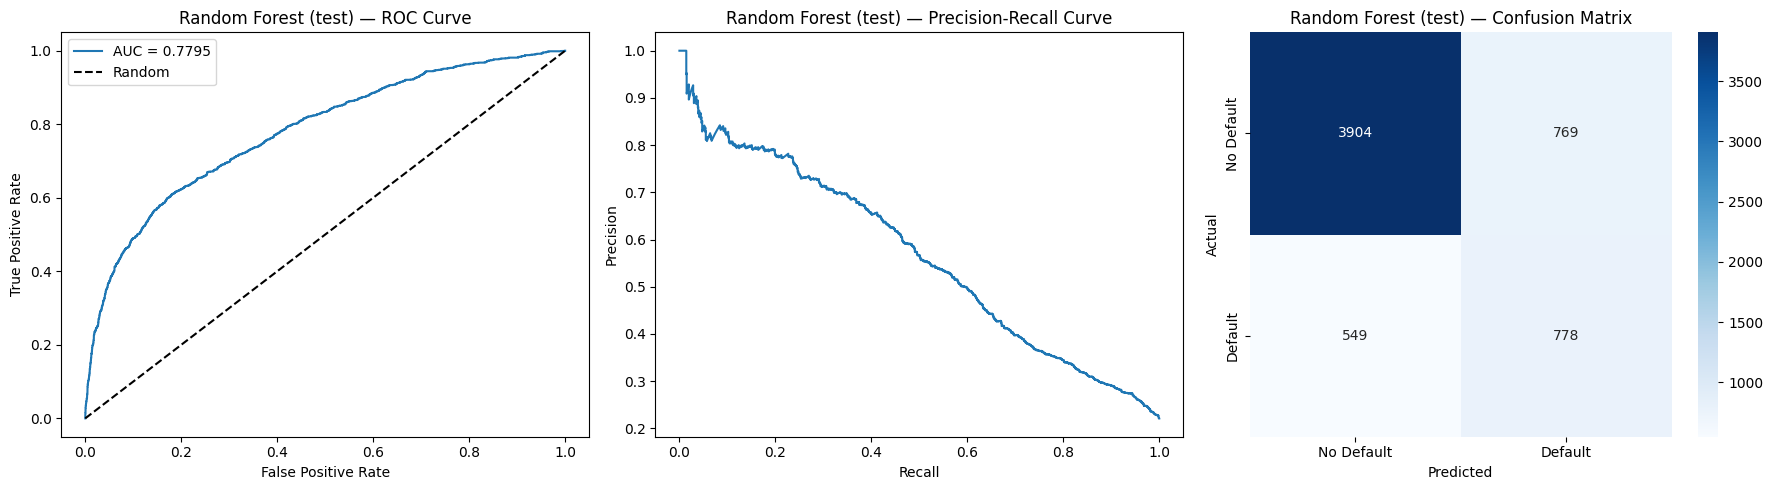

In [22]:
rf = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    min_samples_split=20,
    random_state=0,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print('--- Train performance ---')
rf_train_scores = evaluate_model('Random Forest (train)', rf, X_train, y_train)

print('--- Test performance ---')
rf_test_scores = evaluate_model('Random Forest (test)', rf, X_test, y_test)

## **6.2 XGBoost**

Builds decision trees sequentially — each new tree corrects the mistakes of all previous trees. This boosting approach typically achieves the best performance on structured tabular data.

- `scale_pos_weight` — XGBoost's equivalent of `class_weight='balanced'`. Set to the ratio of negative to positive samples: 23364 / 6636 ≈ 3.52
- `n_estimators=200` — number of boosting rounds
- `use_label_encoder=False` and `eval_metric='logloss'` — suppresses deprecation warnings

scale_pos_weight: 3.52
--- Train performance ---
=== XGBoost (train) ===
  AUC-ROC   : 0.9877
  Recall    : 0.9650
  Precision : 0.7900
  F1 Score  : 0.8687

              precision    recall  f1-score   support

  No Default       0.99      0.93      0.96     18691
     Default       0.79      0.96      0.87      5309

    accuracy                           0.94     24000
   macro avg       0.89      0.95      0.91     24000
weighted avg       0.95      0.94      0.94     24000



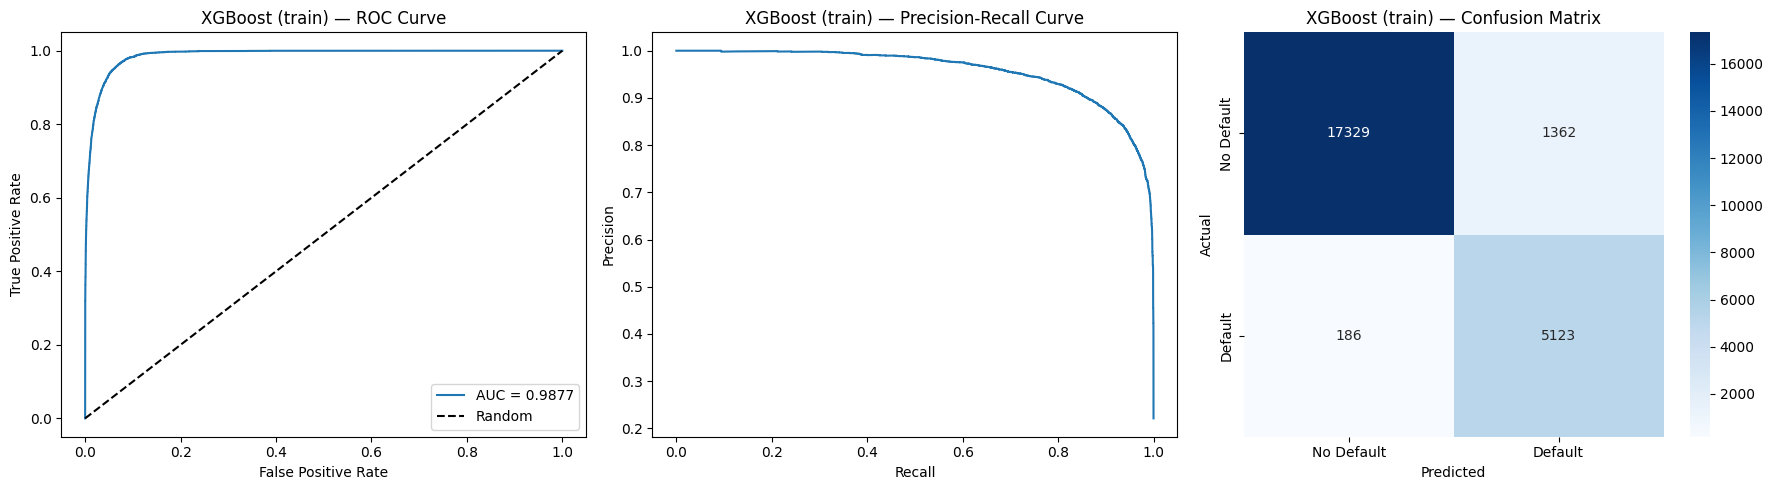

--- Test performance ---
=== XGBoost (test) ===
  AUC-ROC   : 0.7462
  Recall    : 0.5381
  Precision : 0.4786
  F1 Score  : 0.5066

              precision    recall  f1-score   support

  No Default       0.86      0.83      0.85      4673
     Default       0.48      0.54      0.51      1327

    accuracy                           0.77      6000
   macro avg       0.67      0.69      0.68      6000
weighted avg       0.78      0.77      0.77      6000



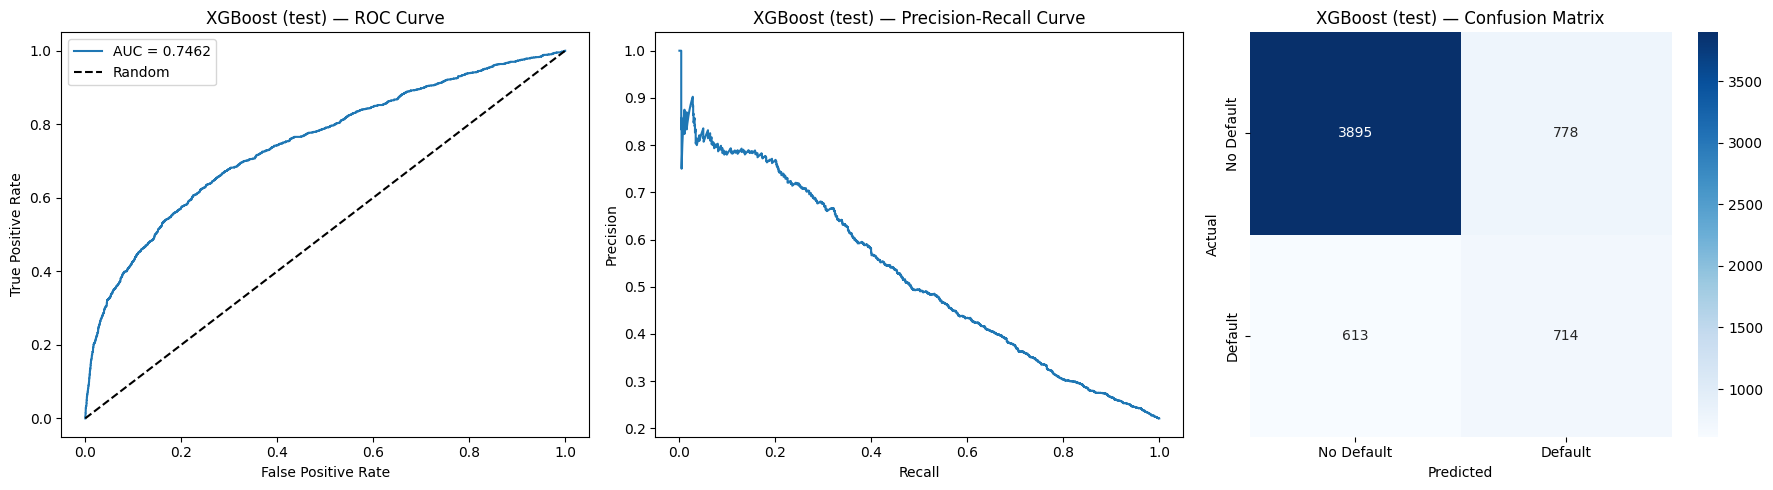

In [23]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    random_state=0,
    eval_metric='logloss',
    n_jobs=-1
)
xgb.fit(X_train, y_train)

print('--- Train performance ---')
xgb_train_scores = evaluate_model('XGBoost (train)', xgb, X_train, y_train)

print('--- Test performance ---')
xgb_test_scores = evaluate_model('XGBoost (test)', xgb, X_test, y_test)

# **7. Compare Models**

Collecting all test set scores into a single table to decide which model to tune further. We rank by AUC-ROC as our primary metric, but also pay attention to Recall — in credit risk, missing a defaulter is the most costly mistake.

                            AUC-ROC  Recall  Precision      F1
name                                                          
Random Forest (test)         0.7795  0.5863     0.5029  0.5414
XGBoost (test)               0.7462  0.5381     0.4786  0.5066
Logistic Regression (test)   0.7459  0.6149     0.4368  0.5108


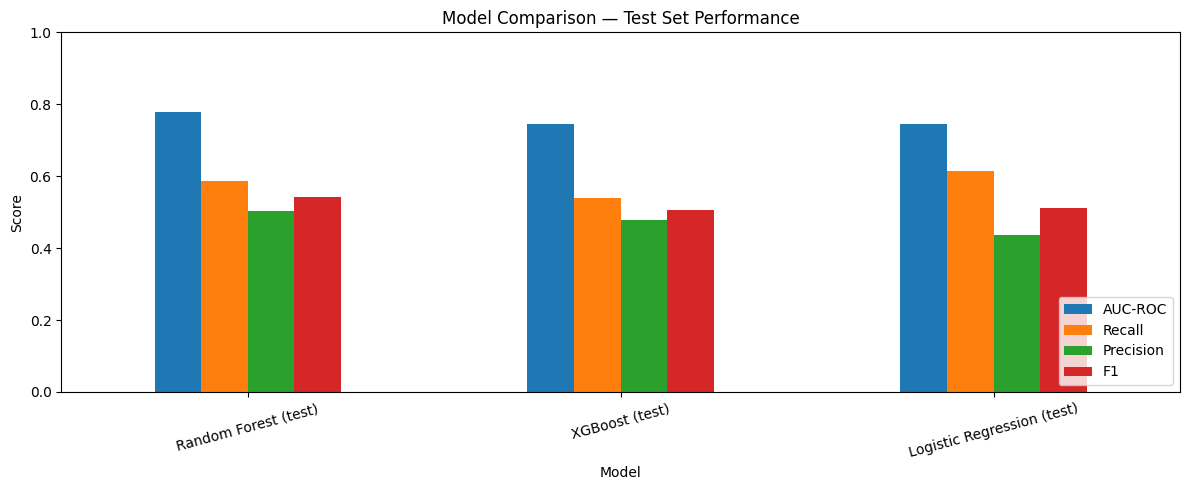

In [24]:
results = pd.DataFrame([lr_test_scores, rf_test_scores, xgb_test_scores])
results = results.set_index('name').sort_values('auc', ascending=False)
results.columns = ['AUC-ROC', 'Recall', 'Precision', 'F1']
print(results.round(4))

# Bar chart comparison
results.plot(kind='bar', figsize=(12, 5), ylim=(0, 1))
plt.title('Model Comparison — Test Set Performance')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# **8. Hyperparameter Tuning — XGBoost**

XGBoost is tuned using `RandomizedSearchCV` which randomly samples combinations from a parameter grid and evaluates each using 5-fold cross-validation. This is faster than GridSearchCV while finding equally good results.

**Scoring metric:** `roc_auc` — consistent with our primary evaluation metric.

**Key parameters being tuned:**
- `n_estimators` — number of boosting rounds
- `max_depth` — how deep each tree can grow
- `learning_rate` — how much each tree corrects the previous one
- `subsample` — fraction of rows sampled per tree
- `colsample_bytree` — fraction of features sampled per tree
- `min_child_weight` — minimum samples needed to make a split

In [25]:
param_grid = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=0,
    eval_metric='logloss',
    n_jobs=-1
)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    random_state=0,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f'\nBest AUC-ROC (CV): {search.best_score_:.4f}')
print(f'Best parameters:')
for param, value in search.best_params_.items():
    print(f'  {param}: {value}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best AUC-ROC (CV): 0.7822
Best parameters:
  subsample: 0.6
  n_estimators: 300
  min_child_weight: 1
  max_depth: 5
  learning_rate: 0.01
  colsample_bytree: 0.6


# **9. Final Evaluation on Test Set**

Using the best model found by `RandomizedSearchCV` for final evaluation on the held-out test set. This is the number that truly matters — the test set has never been seen during training or tuning.

We also compare the tuned model against the untuned XGBoost to quantify how much hyperparameter tuning helped.

--- Tuned XGBoost — Train performance ---
=== XGBoost Tuned (train) ===
  AUC-ROC   : 0.8068
  Recall    : 0.6530
  Precision : 0.4897
  F1 Score  : 0.5597

              precision    recall  f1-score   support

  No Default       0.89      0.81      0.85     18691
     Default       0.49      0.65      0.56      5309

    accuracy                           0.77     24000
   macro avg       0.69      0.73      0.70     24000
weighted avg       0.80      0.77      0.78     24000



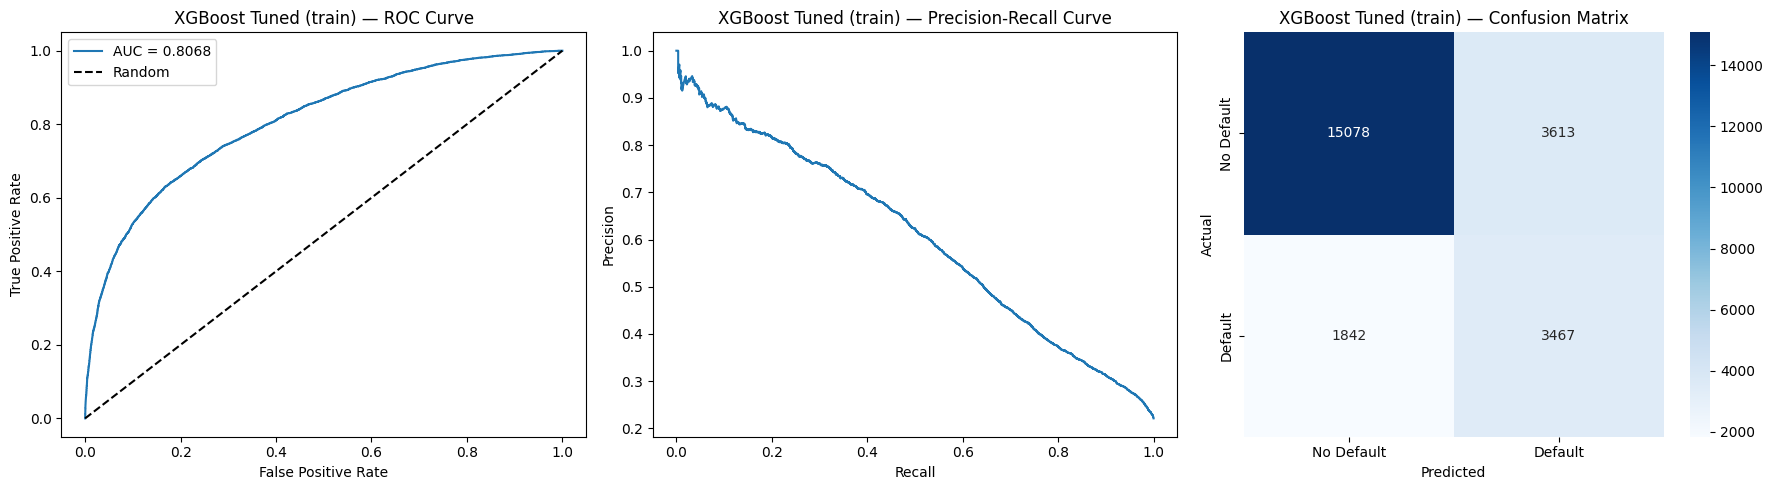

--- Tuned XGBoost — Test performance ---
=== XGBoost Tuned (test) ===
  AUC-ROC   : 0.7805
  Recall    : 0.6240
  Precision : 0.4670
  F1 Score  : 0.5342

              precision    recall  f1-score   support

  No Default       0.88      0.80      0.84      4673
     Default       0.47      0.62      0.53      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.69      6000
weighted avg       0.79      0.76      0.77      6000



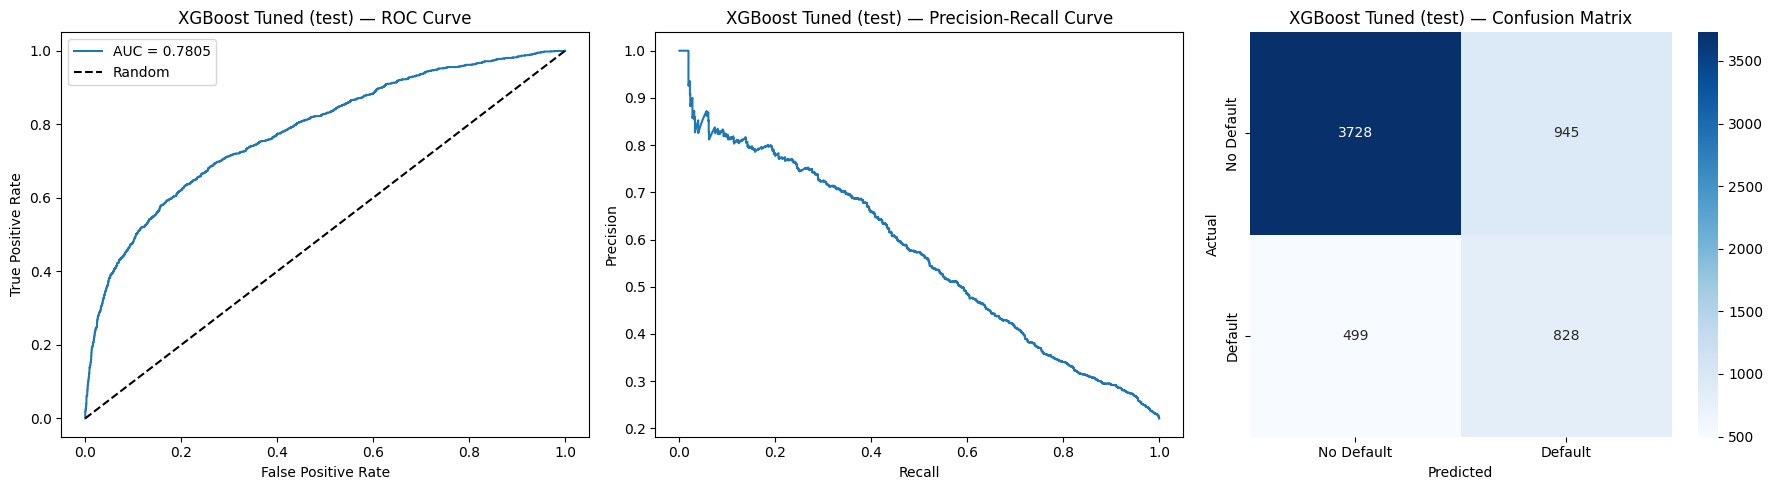

In [26]:
best_model = search.best_estimator_

print('--- Tuned XGBoost — Train performance ---')
xgb_tuned_train_scores = evaluate_model('XGBoost Tuned (train)', best_model, X_train, y_train)

print('--- Tuned XGBoost — Test performance ---')
xgb_tuned_test_scores = evaluate_model('XGBoost Tuned (test)', best_model, X_test, y_test)

In [27]:
# Full comparison including tuned model
final_results = pd.DataFrame([
    lr_test_scores,
    rf_test_scores,
    xgb_test_scores,
    xgb_tuned_test_scores
])
final_results = final_results.set_index('name').sort_values('auc', ascending=False)
final_results.columns = ['AUC-ROC', 'Recall', 'Precision', 'F1']
print('=== Final Model Comparison (Test Set) ===')
print(final_results.round(4))

=== Final Model Comparison (Test Set) ===
                            AUC-ROC  Recall  Precision      F1
name                                                          
XGBoost Tuned (test)         0.7805  0.6240     0.4670  0.5342
Random Forest (test)         0.7795  0.5863     0.5029  0.5414
XGBoost (test)               0.7462  0.5381     0.4786  0.5066
Logistic Regression (test)   0.7459  0.6149     0.4368  0.5108


# **10. Error Analysis**

Understanding *where* and *why* the model makes mistakes is as important as the overall score. We look at two things:

1. **Feature Importances** — which features drove the model's predictions most? Does it align with what we found in EDA?
2. **False Negative Analysis** — who are the defaulters the model missed? Are there patterns in their profiles that could inform future improvements?

## **10.1 Feature Importances**

XGBoost assigns an importance score to each feature based on how often and how effectively it was used to split the data. Higher score = more influential in predicting default.

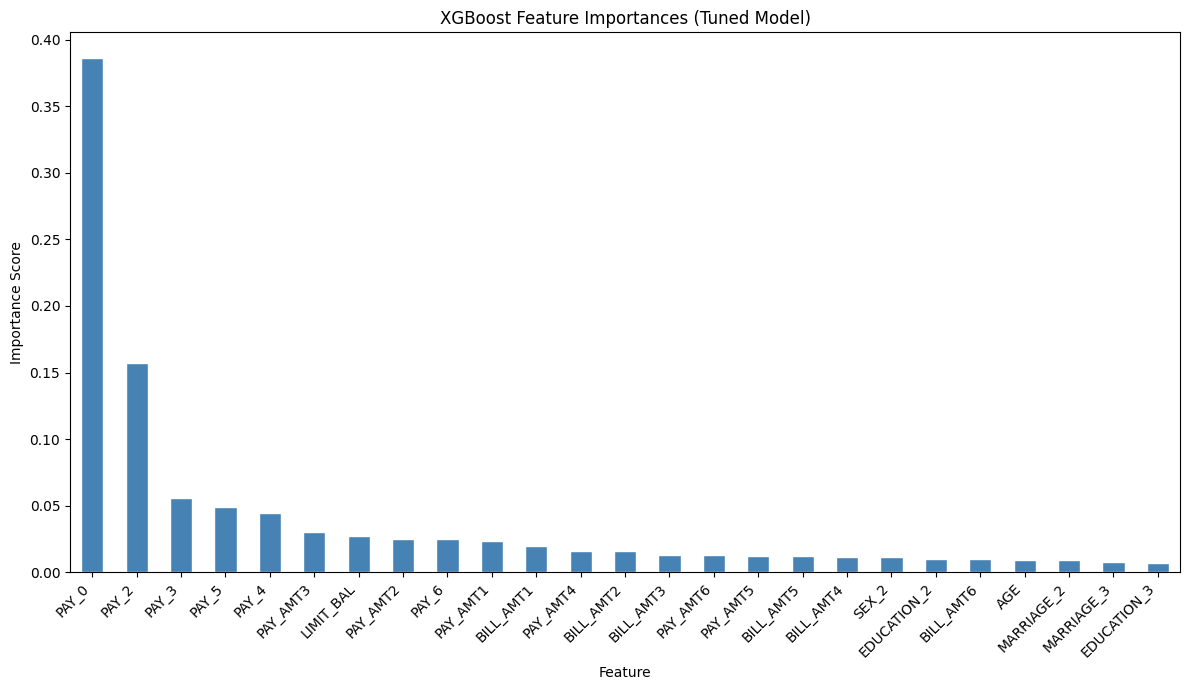

Top 10 most important features:
PAY_0        0.3864
PAY_2        0.1573
PAY_3        0.0559
PAY_5        0.0491
PAY_4        0.0441
PAY_AMT3     0.0303
LIMIT_BAL    0.0272
PAY_AMT2     0.0248
PAY_6        0.0247
PAY_AMT1     0.0236
dtype: float32


In [28]:
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(12, 7))
importances.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('XGBoost Feature Importances (Tuned Model)')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 10 most important features:')
print(importances.head(10).round(4))

## **10.2 False Negative Analysis**

False Negatives are defaulters the model predicted as safe — the most costly mistake in credit risk. We look at their profile (credit limit, payment status, age) to understand what makes them hard to detect.

In [29]:
y_pred_test = best_model.predict(X_test)

# False Negatives: actual default=1, predicted=0
fn_mask = (y_test == 1) & (y_pred_test == 0)
tp_mask = (y_test == 1) & (y_pred_test == 1)

fn_profiles = X_test[fn_mask]
tp_profiles = X_test[tp_mask]

print(f'Total defaulters in test set : {y_test.sum()}')
print(f'Correctly caught (TP)        : {tp_mask.sum()}')
print(f'Missed (FN)                  : {fn_mask.sum()}')
print(f'Miss rate                    : {fn_mask.sum() / y_test.sum() * 100:.1f}%')

# Compare key feature means between caught vs missed defaulters
compare_cols = ['LIMIT_BAL', 'PAY_0', 'PAY_2', 'PAY_AMT1', 'AGE']
comparison = pd.DataFrame({
    'Caught Defaulters (TP)': tp_profiles[compare_cols].mean(),
    'Missed Defaulters (FN)': fn_profiles[compare_cols].mean()
})
print('\nProfile comparison (scaled values):')
print(comparison.round(3))

Total defaulters in test set : 1327
Correctly caught (TP)        : 828
Missed (FN)                  : 499
Miss rate                    : 37.6%

Profile comparison (scaled values):
           Caught Defaulters (TP)  Missed Defaulters (FN)
LIMIT_BAL                  -0.395                  -0.028
PAY_0                       1.143                  -0.282
PAY_2                       0.906                  -0.248
PAY_AMT1                   -0.600                   0.213
AGE                         0.108                   0.043


# **11. Save Best Model**

Saving the tuned XGBoost model to disk so it can be loaded in Notebook 04 for interpretation and explainability analysis without retraining.

In [30]:
BASE = r'C:\Users\jensd\Downloads\Datasets School\Data Science Map\credit-risk-project'
model_path = os.path.join(BASE, 'models', 'xgb_best_model.pkl')
joblib.dump(best_model, model_path)
print(f'Best model saved: {model_path}')

Best model saved: C:\Users\jensd\Downloads\Datasets School\Data Science Map\credit-risk-project\models\xgb_best_model.pkl


# **12. Summary**

### Models Trained:

| Model | Role | Class Imbalance Handling |
|-------|------|--------------------------|
| Logistic Regression | Baseline | `class_weight='balanced'` |
| Random Forest | Candidate | `class_weight='balanced'` |
| XGBoost | Candidate + Final | `scale_pos_weight` |
| XGBoost (Tuned) | Best model | `scale_pos_weight` + RandomizedSearchCV |

### Evaluation Approach:
- **Primary metric:** AUC-ROC — threshold-independent, robust to class imbalance
- **Secondary metric:** Recall — catching defaulters is the most critical business objective
- **Not used:** Accuracy — misleading on imbalanced data (a model predicting all "no default" scores 77.88%)
- Train and test performance compared for all models to detect overfitting

### Key Findings:
- PAY_0 and PAY_2 are the strongest predictors — consistent with EDA findings (r=0.32)
- LIMIT_BAL is the strongest negative predictor — consistent with EDA findings (r=-0.15)
- Missed defaulters (False Negatives) tend to have recent on-time payments despite eventual default

### Output Files:
- `models/xgb_best_model.pkl` — tuned XGBoost model
- `models/scaler.pkl` — fitted scaler (from Notebook 02)

### Next Steps (Notebook 04 — Interpretation & Conclusions):
- SHAP values for global and individual prediction explanations
- XAI (Explainable AI) — understand *why* the model flags specific customers
- Business recommendations based on model findings